In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.cm as cm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyhdf.SD import SD, SDC
import math
import pprint

import warnings
warnings.filterwarnings("ignore")

scale factor: 0.0010000000474974513
AOD is: 0.9300000441726297


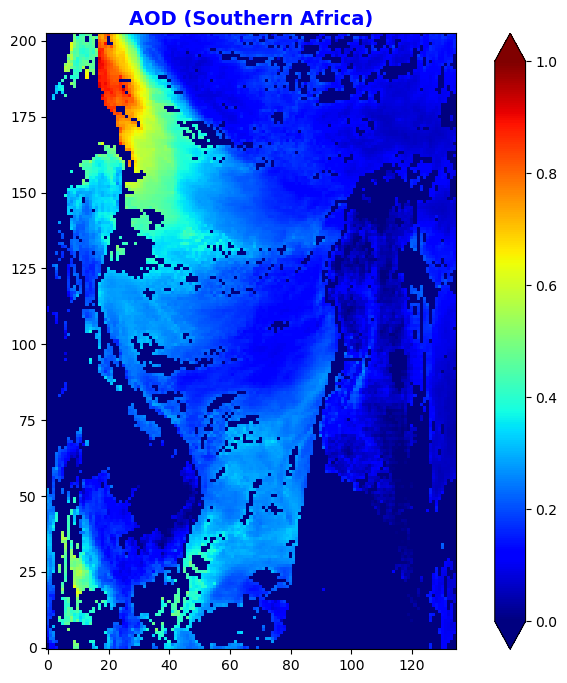

In [2]:
# Load HDF4 file
mod_data = 'MOD04_L2.A2024214.0645.061.2024214192459.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Optical_Depth_Land_And_Ocean')      
# pprint.pprint(sds_attr1.attributes())

aod= my_data.select('Optical_Depth_Land_And_Ocean')   
aod_data= aod.get()
# print(aod_data.shape)

m_scal=my_data.select('Optical_Depth_Land_And_Ocean')
m_scal_val=m_scal.get()
attributes=aod.attributes()
scale= attributes.get('scale_factor')
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
aod1=aod_data*scale
print('AOD is:', np.max(aod1))

fig, ax= plt.subplots(figsize = (10,8))     #
img=ax.imshow(aod1, cmap='jet', vmin=0, vmax=1, interpolation='nearest', origin='lower')        # np.flipud(rgb)
ax.set_title('AOD (Southern Africa)', fontsize=14, color='b', fontweight='bold')
cbar= plt.colorbar(img, ax=ax, extend='both')
# plt.savefig('AOD_SA', dpi=300)
plt.show()

Scale factor: 0.0010000000474974513
Max AOD: 0.9300000441726297


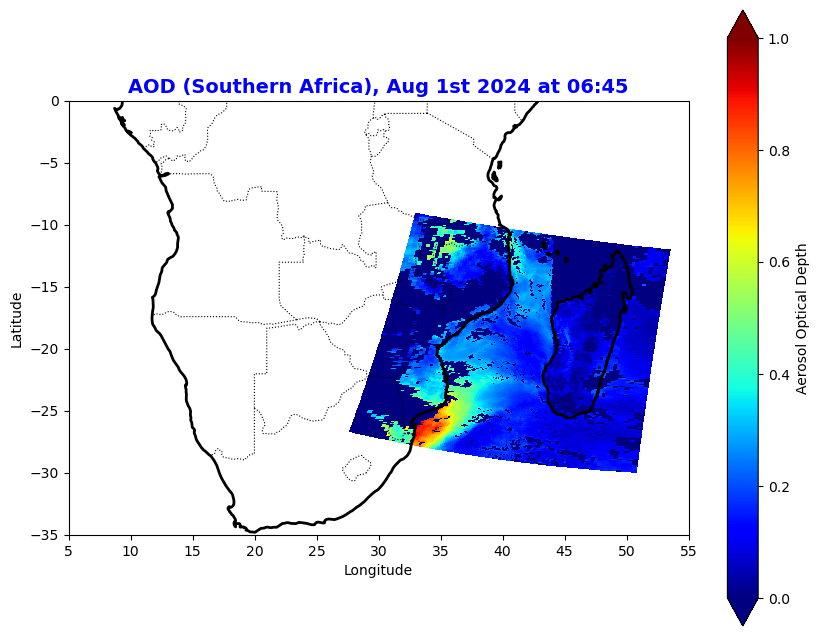

In [3]:
# Load HDF4 file
mod_data = 'MOD04_L2.A2024214.0645.061.2024214192459.hdf'
my_data = SD(mod_data, SDC.READ)

# Print dataset names
mydata_SDSs = my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx, sds)

# Select dataset and extract attributes
aod = my_data.select('Optical_Depth_Land_And_Ocean')
aod_data = aod.get()

# Get scale factor
attributes = aod.attributes()
scale = attributes.get('scale_factor', 1)  # Default to 1 if not found
print('Scale factor:', scale)

# Apply scaling
aod1 = aod_data * scale
print('Max AOD:', np.max(aod1))

# Generate latitudes and longitudes for Southern Africa
longitudes = my_data.select('Longitude').get()
latitudes = my_data.select('Latitude').get() 

lon_min, lon_max = 5, 55
lat_min, lat_max = -35, 0

# print("Longitude range in dataset:", longitudes.min(), longitudes.max())
# print("Latitude range in dataset:", latitudes.min(), latitudes.max())

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

img = ax.pcolormesh(longitudes, latitudes, aod1, vmin=0, vmax=1, transform=ccrs.PlateCarree(), cmap='jet')
ax.add_feature(cfeature.COASTLINE, linewidth=2, edgecolor='black')     # np.flipud(aod1)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.set_xticks(np.arange(lon_min, lon_max + 5, 5), crs=ccrs.PlateCarree())  
ax.set_yticks(np.arange(lat_min, lat_max + 5, 5), crs=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title('AOD (Southern Africa), Aug 1st 2024 at 06:45', fontsize=14, color='b', fontweight='bold')
plt.colorbar(img, ax=ax, extend='both', label='Aerosol Optical Depth')
plt.savefig('image1.png')
plt.show()

Scale factor: 0.0010000000474974513
Max AOD: 4.966000235872343


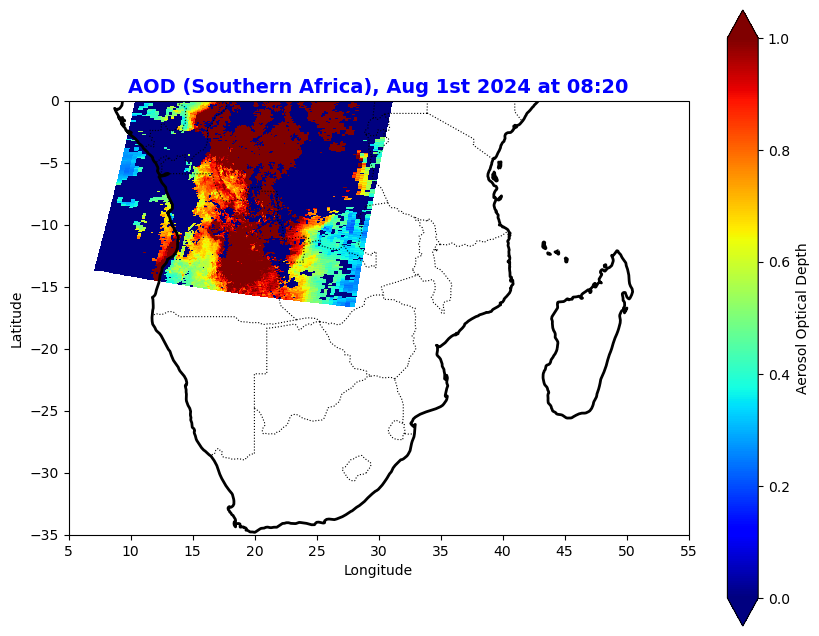

In [4]:
# Load HDF4 file
mod_data = 'MOD04_L2.A2024214.0820.061.2024214192219.hdf'
my_data = SD(mod_data, SDC.READ)

# Print dataset names
mydata_SDSs = my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx, sds)

# Select dataset and extract attributes
aod = my_data.select('Optical_Depth_Land_And_Ocean')
aod_data = aod.get()

# Get scale factor
attributes = aod.attributes()
scale = attributes.get('scale_factor', 1)  # Default to 1 if not found
print('Scale factor:', scale)

# Apply scaling
aod1 = aod_data * scale
print('Max AOD:', np.max(aod1))

# Generate latitudes and longitudes for Southern Africa
longitudes = my_data.select('Longitude').get()
latitudes = my_data.select('Latitude').get() 

lon_min, lon_max = 5, 55
lat_min, lat_max = -35, 0

# print("Longitude range in dataset:", longitudes.min(), longitudes.max())
# print("Latitude range in dataset:", latitudes.min(), latitudes.max())

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

img = ax.pcolormesh(longitudes, latitudes, aod1, vmin=0, vmax=1, transform=ccrs.PlateCarree(), cmap='jet')
ax.add_feature(cfeature.COASTLINE, linewidth=2, edgecolor='black')     # np.flipud(aod1)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.set_xticks(np.arange(lon_min, lon_max + 5, 5), crs=ccrs.PlateCarree())  
ax.set_yticks(np.arange(lat_min, lat_max + 5, 5), crs=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title('AOD (Southern Africa), Aug 1st 2024 at 08:20', fontsize=14, color='b', fontweight='bold')
plt.colorbar(img, ax=ax, extend='both', label='Aerosol Optical Depth')
plt.savefig('image2.png')
plt.show()

Scale factor: 0.0010000000474974513
Max AOD: 4.67300022195559


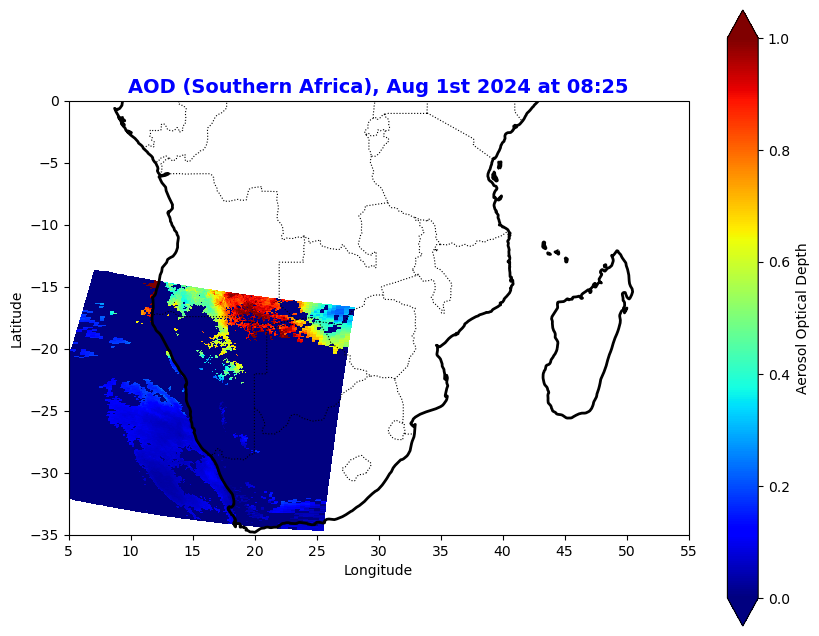

In [5]:
 # Load HDF4 file
mod_data = 'MOD04_L2.A2024214.0825.061.2024214192101.hdf'
my_data = SD(mod_data, SDC.READ)

# Print dataset names
mydata_SDSs = my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx, sds)

# Select dataset and extract attributes
aod = my_data.select('Optical_Depth_Land_And_Ocean')
aod_data = aod.get()

# Get scale factor
attributes = aod.attributes()
scale = attributes.get('scale_factor', 1)  # Default to 1 if not found
print('Scale factor:', scale)

# Apply scaling
aod1 = aod_data * scale
print('Max AOD:', np.max(aod1))

# Generate latitudes and longitudes for Southern Africa
longitudes = my_data.select('Longitude').get()
latitudes = my_data.select('Latitude').get() 

lon_min, lon_max = 5, 55
lat_min, lat_max = -35, 0

# print("Longitude range in dataset:", longitudes.min(), longitudes.max())
# print("Latitude range in dataset:", latitudes.min(), latitudes.max())

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

img = ax.pcolormesh(longitudes, latitudes, aod1, vmin=0, vmax=1, transform=ccrs.PlateCarree(), cmap='jet')
ax.add_feature(cfeature.COASTLINE, linewidth=2, edgecolor='black')     # np.flipud(aod1)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.set_xticks(np.arange(lon_min, lon_max + 5, 5), crs=ccrs.PlateCarree())  
ax.set_yticks(np.arange(lat_min, lat_max + 5, 5), crs=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title('AOD (Southern Africa), Aug 1st 2024 at 08:25', fontsize=14, color='b', fontweight='bold')
plt.colorbar(img, ax=ax, extend='both', label='Aerosol Optical Depth')
# plt.savefig('image.png')
plt.show()